In [1]:
import os
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from torchvision import transforms
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 2060


In [7]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Processed files exist:", PROCESSED_DIR.exists())

Project root: D:\UTS\Courseworks\Year2\Semester3\94691DeepLearning\Assignment3\Development
Processed directory: D:\UTS\Courseworks\Year2\Semester3\94691DeepLearning\Assignment3\Development\data\processed
Processed files exist: True


In [9]:
from collections import Counter

class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        for tok in self.SPECIAL_TOKENS:
            self._add(tok)

    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx)
            self.word2idx[word] = i
            self.idx2word[i] = word

    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        counter = Counter()
        for tokens in tokenized_captions:
            counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq:
                vocab._add(word)
        vocab.freq = counter
        return vocab

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def start_idx(self):
        return self.word2idx[self.START]

    @property
    def end_idx(self):
        return self.word2idx[self.END]

    @property
    def unk_idx(self):
        return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END:
                    break
                if w in (self.PAD, self.START):
                    continue
            words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

In [10]:
with open(PROCESSED_DIR / "vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

with open(PROCESSED_DIR / "train_data.pkl", "rb") as f:
    train_data = pickle.load(f)

with open(PROCESSED_DIR / "val_data.pkl", "rb") as f:
    val_data = pickle.load(f)

with open(PROCESSED_DIR / "test_data.pkl", "rb") as f:
    test_data = pickle.load(f)

with open(PROCESSED_DIR / "config.pkl", "rb") as f:
    config = pickle.load(f)

print("Vocabulary size:", len(vocab))
print("Train images:", len(train_data))
print("Validation images:", len(val_data))
print("Test images:", len(test_data))
print("Config:", config)

Vocabulary size: 3214
Train images: 5279
Validation images: 1131
Test images: 1132
Config: {'random_seed': 42, 'min_word_freq': 5, 'max_caption_length': 25, 'min_caption_length': 3, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'filter_rejected': True, 'filter_precanned': True, 'vocab_size': 3214, 'imagenet_mean': [0.485, 0.456, 0.406], 'imagenet_std': [0.229, 0.224, 0.225]}


In [11]:
IMAGENET_MEAN = config["imagenet_mean"]
IMAGENET_STD = config["imagenet_std"]

def get_train_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_eval_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

In [12]:
class VizWizCaptionDataset(Dataset):
    """
    train mode: returns (image, caption_ids) for one image-caption pair.
    eval mode: returns (image, list_of_reference_caption_ids) for each image.
    """
    def __init__(self, data, vocab, transform, mode="train"):
        assert mode in ("train", "eval")
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.mode = mode

        if mode == "train":
            self.samples = [
                (item["image_path"], cap)
                for item in data
                for cap in item["captions_tokens"]
            ]
        else:
            self.samples = [
                (item["image_path"], item["captions_tokens"])
                for item in data
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, caps = self.samples[idx]
        image = self.transform(Image.open(path).convert("RGB"))

        if self.mode == "train":
            caption_ids = self.vocab.encode(caps)
            return image, torch.tensor(caption_ids, dtype=torch.long)

        refs = [self.vocab.encode(c, add_special=False) for c in caps]
        return image, refs


def collate_train(batch):
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = torch.tensor([len(c) for c in captions], dtype=torch.long)
    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=vocab.pad_idx
    )
    return images, captions, lengths


def collate_eval(batch):
    images, refs = zip(*batch)
    images = torch.stack(images, dim=0)
    return images, list(refs)

In [13]:
BATCH_SIZE = 32

train_ds = VizWizCaptionDataset(
    train_data,
    vocab,
    get_train_transform(),
    mode="train"
)

val_ds = VizWizCaptionDataset(
    val_data,
    vocab,
    get_eval_transform(),
    mode="eval"
)

test_ds = VizWizCaptionDataset(
    test_data,
    vocab,
    get_eval_transform(),
    mode="eval"
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_train
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_eval
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_eval
)

print("Training image-caption pairs:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))

images, captions, lengths = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Caption batch shape:", captions.shape)
print("Caption lengths:", lengths[:5].tolist())
print("Decoded example:", vocab.decode(captions[0].tolist()))

Training image-caption pairs: 23176
Validation images: 1131
Test images: 1132
Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 23])
Caption lengths: [15, 21, 11, 21, 23]
Decoded example: a person holding a pear on a stick in front of a table


In [14]:
class MobileNetEncoder(nn.Module):
    def __init__(self, embed_size=256, train_encoder=False):
        super().__init__()

        weights = MobileNet_V3_Large_Weights.DEFAULT
        mobilenet = mobilenet_v3_large(weights=weights)

        # Keep the convolutional feature extractor and average pooling
        self.features = mobilenet.features
        self.avgpool = mobilenet.avgpool

        # MobileNetV3-Large outputs 960 features before the classifier
        self.fc = nn.Linear(960, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        # Freeze or unfreeze CNN encoder
        for param in self.features.parameters():
            param.requires_grad = train_encoder

    def forward(self, images):
        x = self.features(images)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = self.relu(x)
        x = self.dropout(x)
        return x

In [16]:
class LSTMDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        # Remove the last token because the model predicts the next word
        captions_input = captions[:, :-1]

        embeddings = self.embedding(captions_input)

        # Add image feature as the first input token to the LSTM
        features = features.unsqueeze(1)
        lstm_input = torch.cat((features, embeddings), dim=1)

        outputs, _ = self.lstm(lstm_input)
        outputs = self.dropout(outputs)
        logits = self.fc(outputs)

        return logits


class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512):
        super().__init__()

        self.encoder = MobileNetEncoder(embed_size=embed_size)
        self.decoder = LSTMDecoder(
            embed_size=embed_size,
            hidden_size=hidden_size,
            vocab_size=vocab_size
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        logits = self.decoder(features, captions)
        return logits

In [17]:
vocab_size = len(vocab)

model = ImageCaptioningModel(
    vocab_size=vocab_size,
    embed_size=256,
    hidden_size=512
).to(device)

images, captions, lengths = next(iter(train_loader))
images = images.to(device)
captions = captions.to(device)

with torch.no_grad():
    logits = model(images, captions)

print("Images:", images.shape)
print("Captions:", captions.shape)
print("Logits:", logits.shape)
print("Vocab size:", vocab_size)

Images: torch.Size([32, 3, 224, 224])
Captions: torch.Size([32, 24])
Logits: torch.Size([32, 24, 3214])
Vocab size: 3214


In [18]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [19]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc="Training", leave=False)

    for images, captions, lengths in progress_bar:
        images = images.to(device)
        captions = captions.to(device)

        # Forward pass
        logits = model(images, captions)

        # Targets are captions shifted by one position
        targets = captions[:, 1:]

        # Match sequence lengths if needed
        logits = logits[:, :targets.size(1), :]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    return avg_loss

In [20]:
def test_training_step(model, train_loader, criterion, optimizer, device, max_batches=2):
    model.train()

    for batch_idx, (images, captions, lengths) in enumerate(train_loader):
        if batch_idx >= max_batches:
            break

        images = images.to(device)
        captions = captions.to(device)

        logits = model(images, captions)
        targets = captions[:, 1:]
        logits = logits[:, :targets.size(1), :]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Batch {batch_idx + 1} loss: {loss.item():.4f}")

test_training_step(model, train_loader, criterion, optimizer, device, max_batches=2)

Batch 1 loss: 8.0737
Batch 2 loss: 8.0638


In [21]:
NUM_EPOCHS = 3

history_model1 = {
    "train_loss": []
}

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    history_model1["train_loss"].append(train_loss)

    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f}")

Training:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [1/3] Train Loss: 5.3391


Training:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [2/3] Train Loss: 4.8824


Training:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [3/3] Train Loss: 4.7436


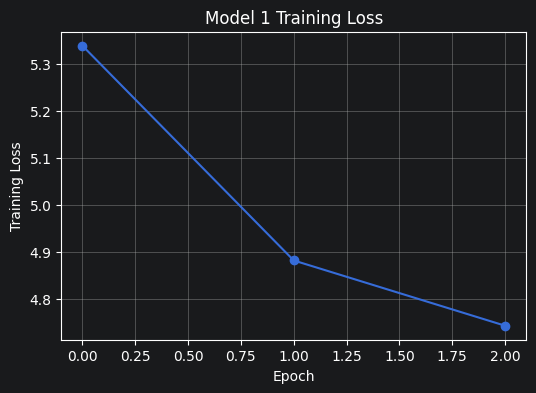

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(history_model1["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Model 1 Training Loss")
plt.grid(True)
plt.show()

In [23]:
def generate_caption(model, image, vocab, device, max_length=25):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encoder(image)

        generated_ids = []
        input_word = torch.tensor([[vocab.start_idx]], dtype=torch.long).to(device)

        hidden = None

        for _ in range(max_length):
            embedding = model.decoder.embedding(input_word)

            if len(generated_ids) == 0:
                lstm_input = torch.cat((features.unsqueeze(1), embedding), dim=1)
            else:
                lstm_input = embedding

            output, hidden = model.decoder.lstm(lstm_input, hidden)
            logits = model.decoder.fc(output[:, -1, :])

            predicted_id = logits.argmax(dim=1).item()

            if predicted_id == vocab.end_idx:
                break

            generated_ids.append(predicted_id)
            input_word = torch.tensor([[predicted_id]], dtype=torch.long).to(device)

    return vocab.decode(generated_ids, strip_special=True)

In [24]:
sample_image, sample_refs = val_ds[0]

generated_caption = generate_caption(
    model,
    sample_image,
    vocab,
    device,
    max_length=25
)

print("Generated caption:")
print(generated_caption)

print("\nReference captions:")
for i, ref in enumerate(sample_refs[:5]):
    print(f"{i+1}. {vocab.decode(ref)}")

Generated caption:
of <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

Reference captions:
1. a package of chicken flavored stuffing mix on a counter in front of a blue object
2. the directions on the back of a box of stuffing mix stands on a wooden counter
3. the back of a box of chicken flavored stuffing mix with cooking directions written in front of a water bottle
4. a box of stuffing is sitting on the counter
5. a package of chicken flavored stuffing mix showing cooking directions


In [25]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def evaluate_bleu(model, data_loader, vocab, device, max_batches=None):
    model.eval()

    all_references = []
    all_candidates = []

    smoothie = SmoothingFunction().method1

    with torch.no_grad():
        for batch_idx, (images, refs_batch) in enumerate(tqdm(data_loader, desc="Evaluating BLEU")):
            if max_batches is not None and batch_idx >= max_batches:
                break

            for image, refs in zip(images, refs_batch):
                generated = generate_caption(model, image, vocab, device)
                candidate = generated.split()

                references = [
                    vocab.decode(ref).split()
                    for ref in refs
                ]

                all_candidates.append(candidate)
                all_references.append(references)

    bleu1 = corpus_bleu(all_references, all_candidates, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(all_references, all_candidates, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(all_references, all_candidates, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(all_references, all_candidates, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4
    }

In [26]:
model1_bleu_sample = evaluate_bleu(
    model,
    val_loader,
    vocab,
    device,
    max_batches=10
)

model1_bleu_sample

Evaluating BLEU:   0%|          | 0/71 [00:00<?, ?it/s]

{'BLEU-1': 0.16433208062863,
 'BLEU-2': 0.0649360357055496,
 'BLEU-3': 0.028949468219693658,
 'BLEU-4': 0.011866685962248127}

In [27]:
model1_bleu = evaluate_bleu(
    model,
    val_loader,
    vocab,
    device,
    max_batches=None
)

model1_bleu

Evaluating BLEU:   0%|          | 0/71 [00:00<?, ?it/s]

{'BLEU-1': 0.17310584452626662,
 'BLEU-2': 0.06666326529919148,
 'BLEU-3': 0.02916333810209217,
 'BLEU-4': 0.013123067133727025}

In [28]:
RESULTS_DIR = PROJECT_ROOT / "results" / "alesh"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = RESULTS_DIR / "alesh_model_1_mobilenet_lstm.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history_model1,
    "bleu_scores": model1_bleu,
    "config": {
        "student": "alesh",
        "model_name": "Model 1 MobileNetV3-Large + LSTM",
        "encoder": "MobileNetV3-Large",
        "decoder": "LSTM",
        "attention": False,
        "embed_size": 256,
        "hidden_size": 512,
        "epochs": NUM_EPOCHS,
        "learning_rate": 1e-4,
        "vocab_size": len(vocab)
    }
}, checkpoint_path)

print("Model 1 checkpoint saved to:")
print(checkpoint_path)

Model 1 checkpoint saved to:
D:\UTS\Courseworks\Year2\Semester3\94691DeepLearning\Assignment3\Development\results\alesh\alesh_model_1_mobilenet_lstm.pth


In [29]:
class MobileNetAttentionEncoder(nn.Module):
    def __init__(self, encoder_dim=960, train_encoder=False):
        super().__init__()

        weights = MobileNet_V3_Large_Weights.DEFAULT
        mobilenet = mobilenet_v3_large(weights=weights)

        self.features = mobilenet.features
        self.encoder_dim = encoder_dim

        for param in self.features.parameters():
            param.requires_grad = train_encoder

    def forward(self, images):
        features = self.features(images)

        # Convert from [batch, channels, height, width]
        # to [batch, num_pixels, encoder_dim]
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))

        return features

In [30]:
encoder_test = MobileNetAttentionEncoder().to(device)

images, captions, lengths = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    spatial_features = encoder_test(images)

print("Input images:", images.shape)
print("Spatial features:", spatial_features.shape)

Input images: torch.Size([32, 3, 224, 224])
Spatial features: torch.Size([32, 49, 960])


In [31]:
class AdditiveAttention(nn.Module):
    def __init__(self, encoder_dim, hidden_size, attention_dim):
        super().__init__()

        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(hidden_size, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(hidden).unsqueeze(1)

        attention = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(attention)

        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)

        return context, alpha

In [32]:
class AttentionLSTMDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        encoder_dim=960,
        embed_size=256,
        hidden_size=512,
        attention_dim=256,
        dropout=0.3
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.encoder_dim = encoder_dim

        self.attention = AdditiveAttention(
            encoder_dim=encoder_dim,
            hidden_size=hidden_size,
            attention_dim=attention_dim
        )

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)

        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1) - 1

        embeddings = self.embedding(captions[:, :-1])

        h, c = self.init_hidden_state(encoder_out)

        predictions = torch.zeros(
            batch_size,
            seq_len,
            self.vocab_size
        ).to(encoder_out.device)

        alphas = torch.zeros(
            batch_size,
            seq_len,
            encoder_out.size(1)
        ).to(encoder_out.device)

        for t in range(seq_len):
            context, alpha = self.attention(encoder_out, h)

            lstm_input = torch.cat(
                [embeddings[:, t, :], context],
                dim=1
            )

            h, c = self.lstm_cell(lstm_input, (h, c))

            preds = self.fc(self.dropout(h))

            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha

        return predictions, alphas

In [33]:
class AttentionImageCaptioningModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        encoder_dim=960,
        embed_size=256,
        hidden_size=512,
        attention_dim=256
    ):
        super().__init__()

        self.encoder = MobileNetAttentionEncoder(
            encoder_dim=encoder_dim,
            train_encoder=False
        )

        self.decoder = AttentionLSTMDecoder(
            vocab_size=vocab_size,
            encoder_dim=encoder_dim,
            embed_size=embed_size,
            hidden_size=hidden_size,
            attention_dim=attention_dim
        )

    def forward(self, images, captions):
        encoder_out = self.encoder(images)
        predictions, alphas = self.decoder(encoder_out, captions)
        return predictions, alphas

In [34]:
model2 = AttentionImageCaptioningModel(
    vocab_size=len(vocab),
    encoder_dim=960,
    embed_size=256,
    hidden_size=512,
    attention_dim=256
).to(device)

images, captions, lengths = next(iter(train_loader))
images = images.to(device)
captions = captions.to(device)

with torch.no_grad():
    predictions, alphas = model2(images, captions)

print("Images:", images.shape)
print("Captions:", captions.shape)
print("Predictions:", predictions.shape)
print("Attention weights:", alphas.shape)

Images: torch.Size([32, 3, 224, 224])
Captions: torch.Size([32, 27])
Predictions: torch.Size([32, 26, 3214])
Attention weights: torch.Size([32, 26, 49])


In [36]:
criterion2 = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

optimizer2 = torch.optim.Adam(
    model2.parameters(),
    lr=1e-4
)

print("Loss function:", criterion2)
print("Optimizer:", optimizer2)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [37]:
def train_one_epoch_attention(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc="Training Model 2", leave=False)

    for images, captions, lengths in progress_bar:
        images = images.to(device)
        captions = captions.to(device)

        predictions, alphas = model(images, captions)

        targets = captions[:, 1:]
        predictions = predictions[:, :targets.size(1), :]

        loss = criterion(
            predictions.reshape(-1, predictions.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

In [39]:
def test_attention_training_step(model, train_loader, criterion, optimizer, device, max_batches=2):
    model.train()

    for batch_idx, (images, captions, lengths) in enumerate(train_loader):
        if batch_idx >= max_batches:
            break

        images = images.to(device)
        captions = captions.to(device)

        predictions, alphas = model(images, captions)

        targets = captions[:, 1:]
        predictions = predictions[:, :targets.size(1), :]

        loss = criterion(
            predictions.reshape(-1, predictions.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Batch {batch_idx + 1} loss: {loss.item():.4f}")

test_attention_training_step(model2, train_loader, criterion2, optimizer2, device, max_batches=2)

Batch 1 loss: 8.0358
Batch 2 loss: 8.0192


In [40]:
NUM_EPOCHS_MODEL2 = 10

history_model2 = {
    "train_loss": []
}

for epoch in range(NUM_EPOCHS_MODEL2):
    train_loss = train_one_epoch_attention(
        model2,
        train_loader,
        criterion2,
        optimizer2,
        device
    )

    history_model2["train_loss"].append(train_loss)

    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS_MODEL2}] Train Loss: {train_loss:.4f}")

Training Model 2:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 5.0108


Training Model 2:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [2/10] Train Loss: 4.3218


Training Model 2:   0%|          | 0/725 [00:00<?, ?it/s]

...

Epoch [8/10] Train Loss: 3.4272


Training Model 2:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 3.3497


Training Model 2:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 3.2769


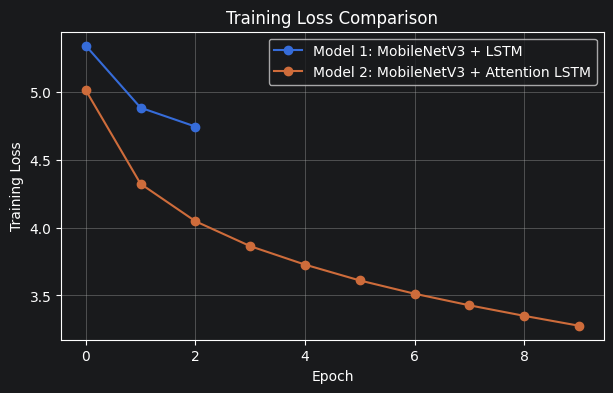

In [42]:
plt.figure(figsize=(7, 4))
plt.plot(history_model1["train_loss"], marker="o", label="Model 1: MobileNetV3 + LSTM")
plt.plot(history_model2["train_loss"], marker="o", label="Model 2: MobileNetV3 + Attention LSTM")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
def generate_caption_attention(model, image, vocab, device, max_length=25):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_out = model.encoder(image)

        h, c = model.decoder.init_hidden_state(encoder_out)

        input_word = torch.tensor([vocab.start_idx], dtype=torch.long).to(device)

        generated_ids = []
        attention_weights = []

        for _ in range(max_length):
            embedding = model.decoder.embedding(input_word)

            context, alpha = model.decoder.attention(encoder_out, h)

            lstm_input = torch.cat([embedding, context], dim=1)

            h, c = model.decoder.lstm_cell(lstm_input, (h, c))

            logits = model.decoder.fc(model.decoder.dropout(h))

            predicted_id = logits.argmax(dim=1).item()

            if predicted_id == vocab.end_idx:
                break

            generated_ids.append(predicted_id)
            attention_weights.append(alpha.squeeze(0).cpu())

            input_word = torch.tensor([predicted_id], dtype=torch.long).to(device)

    caption = vocab.decode(generated_ids, strip_special=True)
    return caption, attention_weights

In [44]:
sample_image, sample_refs = val_ds[0]

generated_caption2, attention_weights = generate_caption_attention(
    model2,
    sample_image,
    vocab,
    device,
    max_length=25
)

print("Generated caption:")
print(generated_caption2)

print("\nReference captions:")
for i, ref in enumerate(sample_refs[:5]):
    print(f"{i+1}. {vocab.decode(ref)}")

print("\nNumber of attention steps:", len(attention_weights))

Generated caption:
a package of food is on a table

Reference captions:
1. a package of chicken flavored stuffing mix on a counter in front of a blue object
2. the directions on the back of a box of stuffing mix stands on a wooden counter
3. the back of a box of chicken flavored stuffing mix with cooking directions written in front of a water bottle
4. a box of stuffing is sitting on the counter
5. a package of chicken flavored stuffing mix showing cooking directions

Number of attention steps: 8


In [45]:
def evaluate_bleu_attention(model, data_loader, vocab, device, max_batches=None):
    model.eval()

    all_references = []
    all_candidates = []

    smoothie = SmoothingFunction().method1

    with torch.no_grad():
        for batch_idx, (images, refs_batch) in enumerate(tqdm(data_loader, desc="Evaluating Model 2 BLEU")):
            if max_batches is not None and batch_idx >= max_batches:
                break

            for image, refs in zip(images, refs_batch):
                generated_caption, _ = generate_caption_attention(
                    model,
                    image,
                    vocab,
                    device,
                    max_length=25
                )

                candidate = generated_caption.split()

                references = [
                    vocab.decode(ref).split()
                    for ref in refs
                ]

                all_candidates.append(candidate)
                all_references.append(references)

    bleu1 = corpus_bleu(
        all_references,
        all_candidates,
        weights=(1, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu2 = corpus_bleu(
        all_references,
        all_candidates,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoothie
    )

    bleu3 = corpus_bleu(
        all_references,
        all_candidates,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smoothie
    )

    bleu4 = corpus_bleu(
        all_references,
        all_candidates,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4
    }

In [46]:
model2_bleu_sample = evaluate_bleu_attention(
    model2,
    val_loader,
    vocab,
    device,
    max_batches=10
)

model2_bleu_sample

Evaluating Model 2 BLEU:   0%|          | 0/71 [00:01<?, ?it/s]

{'BLEU-1': 0.5666699451479003,
 'BLEU-2': 0.36951480933498126,
 'BLEU-3': 0.2287710513505918,
 'BLEU-4': 0.13585422105880496}

In [47]:
model2_bleu = evaluate_bleu_attention(
    model2,
    val_loader,
    vocab,
    device,
    max_batches=None
)

model2_bleu

Evaluating Model 2 BLEU:   0%|          | 0/71 [00:00<?, ?it/s]

{'BLEU-1': 0.553055881426375,
 'BLEU-2': 0.36139279112069445,
 'BLEU-3': 0.22714132343852603,
 'BLEU-4': 0.14258139155959196}

In [41]:
RESULTS_DIR = PROJECT_ROOT / "results" / "alesh"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

model2_checkpoint_path = RESULTS_DIR / "alesh_model_2_mobilenet_attention_lstm.pth"

torch.save({
    "model_state_dict": model2.state_dict(),
    "optimizer_state_dict": optimizer2.state_dict(),
    "history": history_model2,
    "config": {
        "student": "alesh",
        "model_name": "Model 2 MobileNetV3-Large + Attention LSTM",
        "encoder": "MobileNetV3-Large spatial features",
        "decoder": "Attention LSTM",
        "attention": True,
        "embed_size": 256,
        "hidden_size": 512,
        "attention_dim": 256,
        "epochs": NUM_EPOCHS_MODEL2,
        "learning_rate": 1e-4,
        "vocab_size": len(vocab)
    }
}, model2_checkpoint_path)

print("Model 2 checkpoint saved to:")
print(model2_checkpoint_path)

Model 2 checkpoint saved to:
D:\UTS\Courseworks\Year2\Semester3\94691DeepLearning\Assignment3\Development\results\alesh\alesh_model_2_mobilenet_attention_lstm.pth


In [48]:
results_comparison = pd.DataFrame({
    "Model": [
        "Model 1: MobileNetV3 + LSTM",
        "Model 2: MobileNetV3 + Attention LSTM"
    ],
    "Epochs": [3, 10],
    "Final Training Loss": [
        history_model1["train_loss"][-1],
        history_model2["train_loss"][-1]
    ],
    "BLEU-1": [
        model1_bleu["BLEU-1"],
        model2_bleu["BLEU-1"]
    ],
    "BLEU-2": [
        model1_bleu["BLEU-2"],
        model2_bleu["BLEU-2"]
    ],
    "BLEU-3": [
        model1_bleu["BLEU-3"],
        model2_bleu["BLEU-3"]
    ],
    "BLEU-4": [
        model1_bleu["BLEU-4"],
        model2_bleu["BLEU-4"]
    ],
})

results_comparison

,Model,Epochs,Final Training Loss,BLEU-1,BLEU-2,BLEU-3,BLEU-4
0,Model 1: MobileNetV3 + LSTM,3,4.743642,0.173106,0.066663,0.029163,0.013123
1,Model 2: MobileNetV3 + Attention LSTM,10,3.276890,0.553056,0.361393,0.227141,0.142581
